In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/Users/rahaman/Developer/Data_Analytics/Stock_Analysis/data/stock_data.csv')
df.head()


,Unnamed: 0,1. open,2. high,3. low,4. close,5. volume
0,2025-12-10,277.750,279.75,276.44,278.78,33038318.0
1,2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2,2025-12-12,277.900,279.22,276.82,278.28,39532887.0
3,2025-12-15,280.150,280.15,272.84,274.11,50409078.0
4,2025-12-16,272.820,275.50,271.79,274.61,37648628.0


In [3]:
df.rename(columns={'Unnamed: 0' : 'Date'}, inplace=True)
df.head()

,Date,1. open,2. high,3. low,4. close,5. volume
0,2025-12-10,277.750,279.75,276.44,278.78,33038318.0
1,2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2,2025-12-12,277.900,279.22,276.82,278.28,39532887.0
3,2025-12-15,280.150,280.15,272.84,274.11,50409078.0
4,2025-12-16,272.820,275.50,271.79,274.61,37648628.0


In [4]:
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       100 non-null    datetime64[ns]
 1   1. open    100 non-null    float64       
 2   2. high    100 non-null    float64       
 3   3. low     100 non-null    float64       
 4   4. close   100 non-null    float64       
 5   5. volume  100 non-null    float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 4.8 KB


In [5]:
df = df.sort_values('Date')
df.head()

,Date,1. open,2. high,3. low,4. close,5. volume
0,2025-12-10,277.750,279.75,276.44,278.78,33038318.0
1,2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2,2025-12-12,277.900,279.22,276.82,278.28,39532887.0
3,2025-12-15,280.150,280.15,272.84,274.11,50409078.0
4,2025-12-16,272.820,275.50,271.79,274.61,37648628.0


In [6]:
df.reset_index(drop=True, inplace=True)
df.head()

,Date,1. open,2. high,3. low,4. close,5. volume
0,2025-12-10,277.750,279.75,276.44,278.78,33038318.0
1,2025-12-11,279.095,279.59,273.81,278.03,33247986.0
2,2025-12-12,277.900,279.22,276.82,278.28,39532887.0
3,2025-12-15,280.150,280.15,272.84,274.11,50409078.0
4,2025-12-16,272.820,275.50,271.79,274.61,37648628.0


In [7]:
df['SMA_10'] = df['4. close'].rolling(10).mean()
df['SMA_20'] = df['4. close'].rolling(20).mean()

df['Daily_Return'] = df['4. close'].pct_change()

df['Volatility'] = df['Daily_Return'].rolling(10).std()
df.head(50)

,Date,1. open,2. high,3. low,4. close,5. volume,SMA_10,SMA_20,Daily_Return,Volatility
0,2025-12-10,277.750,279.7500,276.440,278.78,33038318.0,NaN,NaN,NaN,NaN
1,2025-12-11,279.095,279.5900,273.810,278.03,33247986.0,NaN,NaN,-0.002690,NaN
2,2025-12-12,277.900,279.2200,276.820,278.28,39532887.0,NaN,NaN,0.000899,NaN
3,2025-12-15,280.150,280.1500,272.840,274.11,50409078.0,NaN,NaN,-0.014985,NaN
4,2025-12-16,272.820,275.5000,271.790,274.61,37648628.0,NaN,NaN,0.001824,NaN
5,2025-12-17,275.010,276.1600,271.640,271.84,50138743.0,NaN,NaN,-0.010087,NaN
6,2025-12-18,273.605,273.6300,266.950,272.19,51630721.0,NaN,NaN,0.001288,NaN
7,2025-12-19,272.145,274.6000,269.900,273.67,144632048.0,NaN,NaN,0.005437,NaN
8,2025-12-22,272.860,273.8800,270.505,270.97,36571827.0,NaN,NaN,-0.009866,NaN
9,2025-12-23,270.840,272.5000,269.560,272.36,29641999.0,274.484,NaN,0.005130,NaN


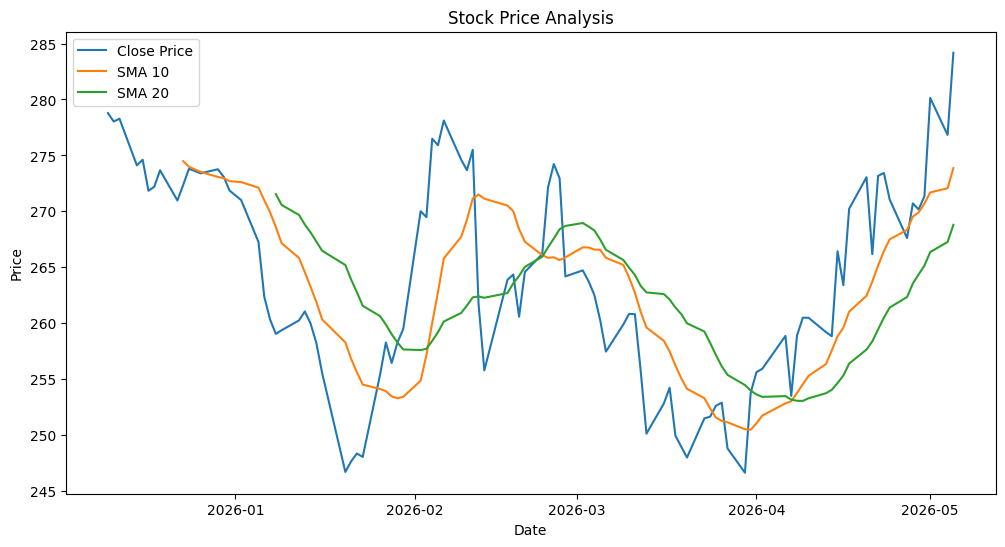

In [8]:
plt.figure(figsize=(12,6))

plt.plot(df['Date'], df['4. close'], label='Close Price')
plt.plot(df['Date'], df['SMA_10'], label='SMA 10')
plt.plot(df['Date'], df['SMA_20'], label='SMA 20')

plt.legend()
plt.title("Stock Price Analysis")
plt.xlabel("Date")
plt.ylabel("Price")

plt.show()

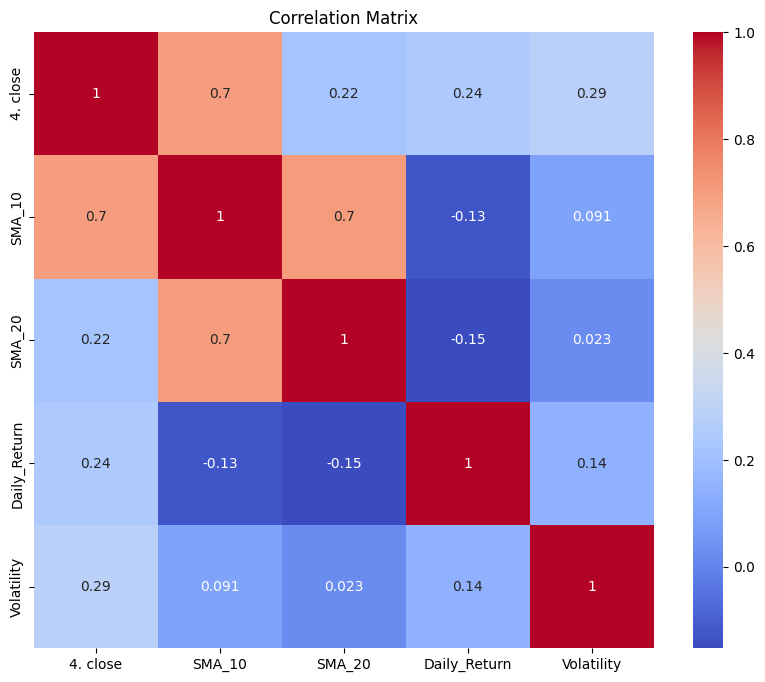

In [9]:
plt.figure(figsize=(10, 8))
corr = df[['4. close', 'SMA_10', 'SMA_20', 'Daily_Return', 'Volatility']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [10]:
df = df.dropna()

X = df[['1. open', '2. high', '3. low', '5. volume', 'SMA_10', 'SMA_20']]
y = df['4. close']

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 1.2531444960655482


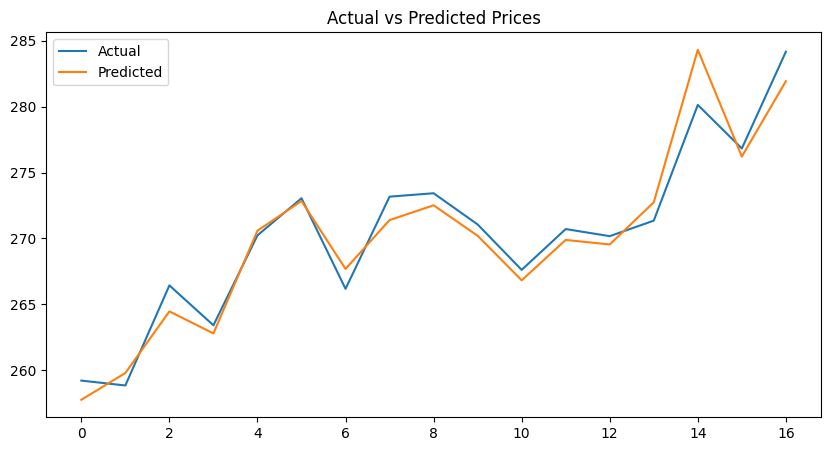

In [12]:
plt.figure(figsize=(10,5))

plt.plot(y_test.values, label='Actual')
plt.plot(predictions, label='Predicted')

plt.legend()
plt.title("Actual vs Predicted Prices")

plt.show()